# Differential Attention + Focused Amplitude/PAR Training and Comparison

This notebook trains `mcldnn_diffattention_amp_focus` and compares it against:

- normal attention: `mcldnn_attention`
- plain differential attention: `mcldnn_diffattention`

The new model keeps the differential-attention backbone but adds focused physical QAM cues:

- sequence features: `A(t)`, `A(t)^2`, `boundary_crossing(t)`, `excess_amplitude(t)`
- global features: `log1p(PAR)`, `amplitude_p95`

Rules followed:

- The new focused diff-attention model is trained from scratch.
- Normal attention and plain diff-attention are trained only if their result CSVs are missing.
- Comparison includes test accuracy, accuracy vs SNR, and training accuracy vs SNR.
- The final zip exports only `experiments/5class_diffattention_amp_focus/...`.


In [3]:
# CELL 1: Setup repo and paths
import os
import sys
import shutil
import subprocess
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, FileLink

os.environ["KERAS_BACKEND"] = "tensorflow"

REPO_URL = "https://github.com/akshlabh/amr-5-class.git"
WORK_DIR = Path("/kaggle/working/amr-5-class")
DATASET = Path("/kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat")


def find_attached_repo():
    """Use an attached repo copy when Kaggle internet/GitHub is unavailable."""
    for root in Path("/kaggle/input").glob("**"):
        if (root / "src" / "train.py").exists() and (root / "configs").exists():
            return root
    return None


if (WORK_DIR / ".git").exists():
    subprocess.run(["git", "-C", str(WORK_DIR), "pull"], check=False)
elif WORK_DIR.exists() and (WORK_DIR / "src" / "train.py").exists():
    print(f"Using existing work dir: {WORK_DIR}")
else:
    attached = find_attached_repo()
    if attached is not None:
        print(f"Copying attached repo from: {attached}")
        if WORK_DIR.exists():
            shutil.rmtree(WORK_DIR)
        shutil.copytree(attached, WORK_DIR)
    else:
        print("Cloning repo from GitHub...")
        subprocess.run(["git", "clone", REPO_URL, str(WORK_DIR)], check=True)

os.chdir(WORK_DIR)
if str(WORK_DIR) not in sys.path:
    sys.path.insert(0, str(WORK_DIR))

NORMAL_DIR = Path("experiments/5class_attention")
DIFF_DIR = Path("experiments/5class_diffattention")
FOCUS_DIR = Path("experiments/5class_diffattention_amp_focus")
COMPARE_DIR = FOCUS_DIR / "comparison_with_normal_and_diffattention"
MODEL_VARIANT = "diffattention_amp_focus_A_A2_boundary_excess_PAR_p95_standard_loss"
VARIANT_FILE = Path("results/model_variant.txt")

required = [
    "src/models/mcldnn_attention.py",
    "src/models/mcldnn_diffattention.py",
    "src/models/mcldnn_diffattention_amp_focus.py",
    "src/features/signal_features.py",
    "configs/exp_5class_attention.yaml",
    "configs/exp_5class_diffattention.yaml",
    "configs/exp_5class_diffattention_amp_focus.yaml",
    "src/train.py",
]

print(f"Working dir: {Path.cwd()}")
print(f"Dataset    : {DATASET}")
print(f"Dataset OK : {DATASET.exists()}")
for f in required:
    print(f"{'OK' if Path(f).exists() else 'MISSING'} {f}")

assert DATASET.exists(), f"Dataset not found: {DATASET}"
for f in required:
    assert Path(f).exists(), f"Required repo file missing: {f}"


Already up to date.
Working dir: /kaggle/working/amr-5-class
Dataset    : /kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat
Dataset OK : True
OK src/models/mcldnn_attention.py
OK src/models/mcldnn_diffattention.py
OK src/models/mcldnn_diffattention_amp_focus.py
OK src/features/signal_features.py
OK configs/exp_5class_attention.yaml
OK configs/exp_5class_diffattention.yaml
OK configs/exp_5class_diffattention_amp_focus.yaml
OK src/train.py


In [4]:
# CELL 2: Verify focused amplitude features and model shapes
import gc
import keras
import keras.backend as K

keras.mixed_precision.set_global_policy("float32")
K.clear_session(); gc.collect()

from src.features.signal_features import extract_amplitude_focus_features
from src.models.mcldnn_attention import build_mcldnn_attention
from src.models.mcldnn_diffattention import build_mcldnn_diffattention
from src.models.mcldnn_diffattention_amp_focus import (
    build_mcldnn_diffattention_amp_focus,
    build_mcldnn_diffattention_amp_focus_extractor,
)

# Synthetic feature shape check
np.random.seed(42)
X_fake = np.random.randn(8, 2, 128).astype("float32")
seq_fake, glob_fake = extract_amplitude_focus_features(X_fake, qam16_boundary=1.5)

print(f"Focused sequence shape : {seq_fake.shape}  expected (8, 128, 4)")
print(f"Focused global shape   : {glob_fake.shape}  expected (8, 2)")
print(f"A(t) range             : [{seq_fake[:,:,0].min():.3f}, {seq_fake[:,:,0].max():.3f}]  expected >= 0")
print(f"A(t)^2 range           : [{seq_fake[:,:,1].min():.3f}, {seq_fake[:,:,1].max():.3f}]  expected >= 0")
print(f"Boundary crossing range: [{seq_fake[:,:,2].min():.1f}, {seq_fake[:,:,2].max():.1f}]  expected 0/1")
print(f"Excess range           : [{seq_fake[:,:,3].min():.3f}, {seq_fake[:,:,3].max():.3f}]  expected >= 0")
print(f"Global first row       : log1p(PAR)={glob_fake[0,0]:.3f}, p95={glob_fake[0,1]:.3f}")

assert seq_fake.shape == (8, 128, 4)
assert glob_fake.shape == (8, 2)
assert seq_fake[:,:,0].min() >= 0
assert seq_fake[:,:,1].min() >= 0
assert seq_fake[:,:,2].min() >= 0 and seq_fake[:,:,2].max() <= 1
assert seq_fake[:,:,3].min() >= 0

normal_model = build_mcldnn_attention(classes=5)
diff_model = build_mcldnn_diffattention(classes=5)
focus_model = build_mcldnn_diffattention_amp_focus(classes=5)
focus_extractor = build_mcldnn_diffattention_amp_focus_extractor(classes=5)

print(f"Normal attention params       : {normal_model.count_params():,}")
print(f"Plain diff-attention params   : {diff_model.count_params():,}")
print(f"Diff+amp-focus params         : {focus_model.count_params():,}")
print(f"Under 300k                    : {'YES' if focus_model.count_params() < 300_000 else 'NO'}")

x1 = np.zeros((4, 2, 128, 1), dtype="float32")
x2 = np.zeros((4, 128, 1), dtype="float32")
x3 = np.zeros((4, 128, 1), dtype="float32")
x4 = np.zeros((4, 128, 4), dtype="float32")
x5 = np.zeros((4, 2), dtype="float32")

pred = focus_model.predict([x1, x2, x3, x4, x5], verbose=0)
pred2, attn = focus_extractor.predict([x1, x2, x3, x4, x5], verbose=0)

print(f"Focus training output shape  : {pred.shape}")
print(f"Focus extractor softmax shape: {pred2.shape}")
print(f"Focus diff-attn map shape    : {attn.shape}")

assert pred.shape == (4, 5)
assert pred2.shape == (4, 5)
assert attn.shape == (4, 2, 124, 124)
assert focus_model.count_params() < 300_000
print("Shape checks passed")

del normal_model, diff_model, focus_model, focus_extractor
K.clear_session(); gc.collect()


Focused sequence shape : (8, 128, 4)  expected (8, 128, 4)
Focused global shape   : (8, 2)  expected (8, 2)
A(t) range             : [0.053, 3.208]  expected >= 0
A(t)^2 range           : [0.003, 10.292]  expected >= 0
Boundary crossing range: [0.0, 1.0]  expected 0/1
Excess range           : [0.000, 1.708]  expected >= 0
Global first row       : log1p(PAR)=2.185, p95=1.988


I0000 00:00:1782936149.671552      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Normal attention params       : 244,341
Plain diff-attention params   : 244,092
Diff+amp-focus params         : 270,868
Under 300k                    : YES


I0000 00:00:1782936154.250115     153 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Focus training output shape  : (4, 5)
Focus extractor softmax shape: (4, 5)
Focus diff-attn map shape    : (4, 2, 124, 124)
Shape checks passed


0

In [5]:
# CELL 3: Train Diff-Attention + Amp-Focus model from scratch
# Existing focused-model outputs are removed first so stale weights are not reused.

if FOCUS_DIR.exists():
    print(f"Removing existing focused diff-attention outputs: {FOCUS_DIR}")
    shutil.rmtree(FOCUS_DIR)

print("Training differential attention + focused amplitude/PAR model from scratch...\n")

env = os.environ.copy()
env["PYTHONUNBUFFERED"] = "1"
process = subprocess.Popen(
    [
        sys.executable, "-u", "src/train.py",
        "--config", "configs/exp_5class_diffattention_amp_focus.yaml",
        "--datasetpath", str(DATASET),
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    env=env,
)

for line in process.stdout:
    print(line, end="", flush=True)

return_code = process.wait()
if return_code != 0:
    raise subprocess.CalledProcessError(return_code, process.args)

(FOCUS_DIR / "results").mkdir(parents=True, exist_ok=True)
(FOCUS_DIR / VARIANT_FILE).write_text(MODEL_VARIANT)

print("\nFocused model training finished.")
print("Checkpoint:", (FOCUS_DIR / "checkpoints" / "best_model.weights.h5").exists())
print("Test score:", (FOCUS_DIR / "results" / "test_score.csv").exists())
print("SNR CSV   :", (FOCUS_DIR / "results" / "acc_per_snr.csv").exists())
print("Variant   :", (FOCUS_DIR / VARIANT_FILE).read_text().strip())


Training differential attention + focused amplitude/PAR model from scratch...

[seed] All seeds fixed to 2016  (Python, NumPy, TensorFlow 2.20.0)

  Experiment : 5class_diffattention_amp_focus
  Model      : mcldnn_diffattention_amp_focus
  Branch     : full
  Dropout    : 0.55
  L2 Dense   : 0.001   L2 LSTM : 0.0001
  SNR Weighted: False
  Initial LR : 0.0005
  SNR Range  : None
  Shuffle Split: False
  Classes    : ['BPSK', 'QPSK', '8PSK', 'QAM16', 'QAM64']
  n_classes  : 5
  Checkpoint : experiments/5class_diffattention_amp_focus/checkpoints/best_model.weights.h5

[dataset] Loading 5 classes: ['BPSK', 'QPSK', '8PSK', 'QAM16', 'QAM64']
[dataset] SNR range: -20 dB to 18 dB  (20 levels)
[dataset] After normalization — train RMS: 1.0000  (should be ≈1.0)
[dataset] Split: 60000 train | 20000 val | 20000 test samples
[train] QAM16 amplitude boundary: T=1.797903 (train-only 95.0th percentile)
[train] Input shapes: IQ=(60000, 2, 128, 1)  I=(60000, 128, 1)  Q=(60000, 128, 1)  AmpSeq=(60000, 

In [6]:
# CELL 4: Ensure baseline comparison results exist
# Normal attention and plain diff-attention are trained only if their result CSVs are missing.
# Their checkpoints/results are used for comparison only and are not exported in the final zip.

BASELINES = [
    ("normal_attention", NORMAL_DIR, "configs/exp_5class_attention.yaml"),
    ("plain_diffattention", DIFF_DIR, "configs/exp_5class_diffattention.yaml"),
]

for name, exp_dir, cfg_path in BASELINES:
    score_path = exp_dir / "results" / "test_score.csv"
    snr_path = exp_dir / "results" / "acc_per_snr.csv"
    if score_path.exists() and snr_path.exists():
        print(f"{name}: existing results found. Using for comparison only.")
    else:
        print(f"{name}: results missing. Training for comparison only...")
        subprocess.run([
            sys.executable, "src/train.py",
            "--config", cfg_path,
            "--datasetpath", str(DATASET),
        ], check=True)
    print(f"  test_score: {score_path.exists()}  acc_per_snr: {snr_path.exists()}")


normal_attention: existing results found. Using for comparison only.
  test_score: True  acc_per_snr: True
plain_diffattention: existing results found. Using for comparison only.
  test_score: True  acc_per_snr: True


In [7]:
# CELL 5: Compare test accuracy and accuracy-vs-SNR for all three models
COMPARE_DIR.mkdir(parents=True, exist_ok=True)

models_info = [
    ("normal_attention", NORMAL_DIR, "Normal attention"),
    ("plain_diffattention", DIFF_DIR, "Plain differential attention"),
    ("diffattention_amp_focus", FOCUS_DIR, "Diff attention + amplitude/PAR focus"),
]

summary_rows = []
snr_frames = []

for key, exp_dir, label in models_info:
    score = pd.read_csv(exp_dir / "results" / "test_score.csv")
    snr_df = pd.read_csv(exp_dir / "results" / "acc_per_snr.csv").rename(columns={"accuracy": f"{key}_acc"})
    snr_frames.append(snr_df)
    summary_rows.append({
        "model": key,
        "label": label,
        "test_loss": float(score.loc[0, "loss"]),
        "test_accuracy": float(score.loc[0, "accuracy"]),
        "mean_snr_accuracy": float(snr_df[f"{key}_acc"].mean()),
        "peak_snr_accuracy": float(snr_df[f"{key}_acc"].max()),
        "peak_snr_db": int(snr_df.loc[snr_df[f"{key}_acc"].idxmax(), "snr"]),
    })

comparison = snr_frames[0]
for frame in snr_frames[1:]:
    comparison = pd.merge(comparison, frame, on="snr", how="inner")

comparison["focus_minus_normal"] = comparison["diffattention_amp_focus_acc"] - comparison["normal_attention_acc"]
comparison["focus_minus_plain_diff"] = comparison["diffattention_amp_focus_acc"] - comparison["plain_diffattention_acc"]

for col in ["normal_attention_acc", "plain_diffattention_acc", "diffattention_amp_focus_acc", "focus_minus_normal", "focus_minus_plain_diff"]:
    comparison[col + "_percent"] = 100.0 * comparison[col]

summary = pd.DataFrame(summary_rows)
summary_csv = COMPARE_DIR / "normal_plain_diff_vs_amp_focus_summary.csv"
comparison_csv = COMPARE_DIR / "normal_plain_diff_vs_amp_focus_acc_per_snr.csv"
summary.to_csv(summary_csv, index=False)
comparison.to_csv(comparison_csv, index=False)

print("Summary:")
display(summary)
print("\nPer-SNR comparison:")
display(comparison)
print(f"Saved: {summary_csv}")
print(f"Saved: {comparison_csv}")


Summary:


,model,label,test_loss,test_accuracy,mean_snr_accuracy,peak_snr_accuracy,peak_snr_db
0,normal_attention,Normal attention,1.156071,0.61235,0.61235,0.927,12
1,plain_diffattention,Plain differential attention,0.933952,0.56130,0.56130,0.793,10
2,diffattention_amp_focus,Diff attention + amplitude/PAR focus,1.250650,0.59205,0.59205,0.845,10



Per-SNR comparison:


,snr,normal_attention_acc,plain_diffattention_acc,diffattention_amp_focus_acc,focus_minus_normal,focus_minus_plain_diff,normal_attention_acc_percent,plain_diffattention_acc_percent,diffattention_amp_focus_acc_percent,focus_minus_normal_percent,focus_minus_plain_diff_percent
0,-20,0.329,0.318,0.351,0.022,0.033,32.9,31.8,35.1,2.2,3.3
1,-18,0.309,0.299,0.336,0.027,0.037,30.9,29.9,33.6,2.7,3.7
2,-16,0.320,0.292,0.338,0.018,0.046,32.0,29.2,33.8,1.8,4.6
3,-14,0.317,0.297,0.339,0.022,0.042,31.7,29.7,33.9,2.2,4.2
4,-12,0.303,0.311,0.339,0.036,0.028,30.3,31.1,33.9,3.6,2.8
5,-10,0.276,0.277,0.301,0.025,0.024,27.6,27.7,30.1,2.5,2.4
6,-8,0.283,0.305,0.306,0.023,0.001,28.3,30.5,30.6,2.3,0.1
7,-6,0.324,0.330,0.329,0.005,-0.001,32.4,33.0,32.9,0.5,-0.1
8,-4,0.400,0.422,0.418,0.018,-0.004,40.0,42.2,41.8,1.8,-0.4
9,-2,0.572,0.614,0.611,0.039,-0.003,57.2,61.4,61.1,3.9,-0.3


Saved: experiments/5class_diffattention_amp_focus/comparison_with_normal_and_diffattention/normal_plain_diff_vs_amp_focus_summary.csv
Saved: experiments/5class_diffattention_amp_focus/comparison_with_normal_and_diffattention/normal_plain_diff_vs_amp_focus_acc_per_snr.csv


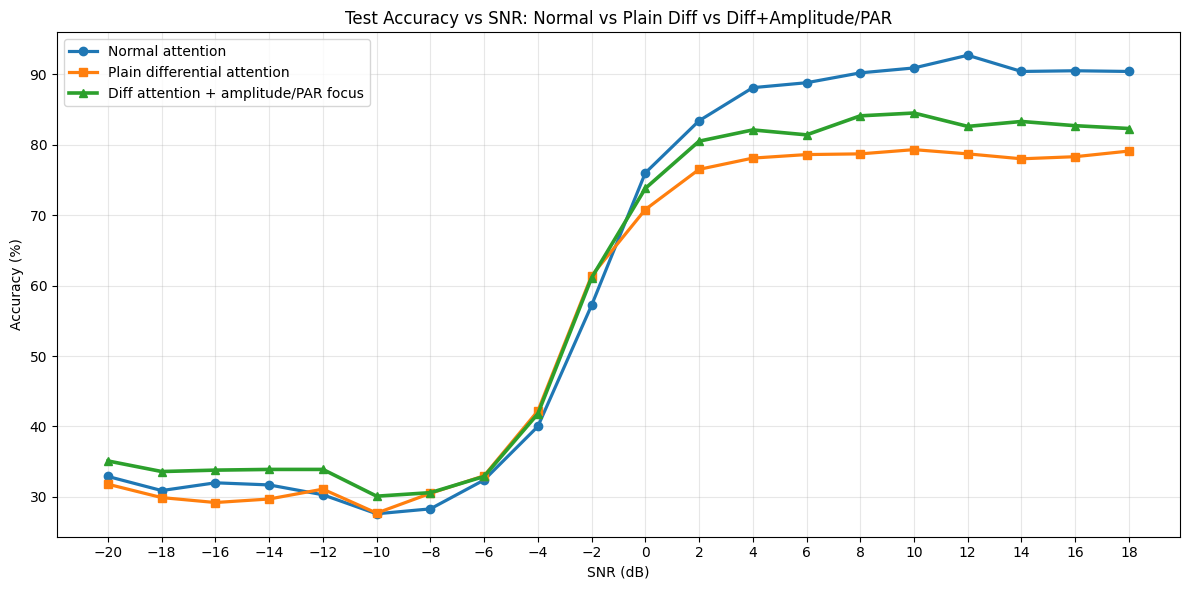

Saved: experiments/5class_diffattention_amp_focus/comparison_with_normal_and_diffattention/normal_plain_diff_vs_amp_focus_acc_vs_snr.png


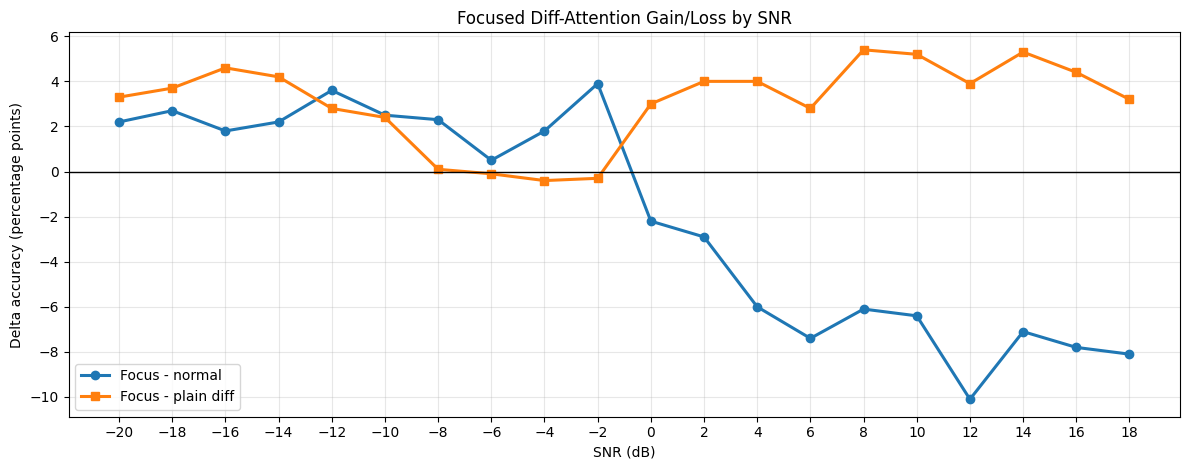

Saved: experiments/5class_diffattention_amp_focus/comparison_with_normal_and_diffattention/amp_focus_delta_by_snr.png


In [8]:
# CELL 6: Plot test accuracy vs SNR and focused-model deltas
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(comparison["snr"], comparison["normal_attention_acc_percent"], marker="o", linewidth=2.3, label="Normal attention")
ax.plot(comparison["snr"], comparison["plain_diffattention_acc_percent"], marker="s", linewidth=2.3, label="Plain differential attention")
ax.plot(comparison["snr"], comparison["diffattention_amp_focus_acc_percent"], marker="^", linewidth=2.6, label="Diff attention + amplitude/PAR focus")
ax.set_title("Test Accuracy vs SNR: Normal vs Plain Diff vs Diff+Amplitude/PAR")
ax.set_xlabel("SNR (dB)")
ax.set_ylabel("Accuracy (%)")
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xticks(comparison["snr"])
plt.tight_layout()
curve_path = COMPARE_DIR / "normal_plain_diff_vs_amp_focus_acc_vs_snr.png"
fig.savefig(curve_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {curve_path}")

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(comparison["snr"], comparison["focus_minus_normal_percent"], marker="o", linewidth=2.2, label="Focus - normal")
ax.plot(comparison["snr"], comparison["focus_minus_plain_diff_percent"], marker="s", linewidth=2.2, label="Focus - plain diff")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Focused Diff-Attention Gain/Loss by SNR")
ax.set_xlabel("SNR (dB)")
ax.set_ylabel("Delta accuracy (percentage points)")
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xticks(comparison["snr"])
plt.tight_layout()
delta_path = COMPARE_DIR / "amp_focus_delta_by_snr.png"
fig.savefig(delta_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {delta_path}")


In [9]:
# CELL 7: Compare training accuracy vs SNR curves
# Evaluates saved best weights on the training split, grouped by SNR.

import keras.backend as K
from src.dataset import load_data, FIVE_CLASS
from src.models.mcldnn_attention import build_mcldnn_attention
from src.models.mcldnn_diffattention import build_mcldnn_diffattention
from src.models.mcldnn_diffattention_amp_focus import build_mcldnn_diffattention_amp_focus
from src.features.signal_features import (
    estimate_qam16_amplitude_boundary,
    extract_amplitude_focus_features,
)

K.clear_session(); gc.collect()

(mods_train, snrs_train, lbl_train), (X_train, Y_train), _, _, (train_idx, _, _) = load_data(
    str(DATASET), FIVE_CLASS, seed=2016, shuffle_split=False
)
train_SNRs = np.array([lbl_train[i][1] for i in train_idx])
TRAIN_SNRS = sorted(set(train_SNRs))
print(f"Training set: {X_train.shape[0]} samples across {len(TRAIN_SNRS)} SNRs")

qam16_boundary = estimate_qam16_amplitude_boundary(
    X_train, Y_train, FIVE_CLASS, quantile=95.0
)
print(f"Train-only QAM16 amplitude boundary: {qam16_boundary:.6f}")


def make_iq_inputs(X):
    return [
        np.expand_dims(X, axis=3).astype("float32"),
        np.expand_dims(X[:, 0, :], axis=2).astype("float32"),
        np.expand_dims(X[:, 1, :], axis=2).astype("float32"),
    ]


def make_focus_inputs(X):
    seq, glob = extract_amplitude_focus_features(X, qam16_boundary=qam16_boundary)
    return make_iq_inputs(X) + [seq, glob]


def slice_inputs(inputs, mask):
    return [arr[mask] for arr in inputs]


def eval_by_snr(model, inputs, Y, snr_labels, snr_values, batch_size=400):
    accs = {}
    for snr in snr_values:
        mask = snr_labels == snr
        score = model.evaluate(slice_inputs(inputs, mask), Y[mask], verbose=0, batch_size=batch_size)
        accs[int(snr)] = float(score[1])
    return accs

normal_inputs = make_iq_inputs(X_train)
diff_inputs = make_iq_inputs(X_train)
focus_inputs = make_focus_inputs(X_train)

normal_model = build_mcldnn_attention(classes=5)
normal_model.load_weights(NORMAL_DIR / "checkpoints" / "best_model.weights.h5")
normal_train_acc = eval_by_snr(normal_model, normal_inputs, Y_train, train_SNRs, TRAIN_SNRS)
print("Normal attention train mean acc:", np.mean(list(normal_train_acc.values())))
del normal_model; K.clear_session(); gc.collect()

diff_model = build_mcldnn_diffattention(classes=5)
diff_model.load_weights(DIFF_DIR / "checkpoints" / "best_model.weights.h5")
diff_train_acc = eval_by_snr(diff_model, diff_inputs, Y_train, train_SNRs, TRAIN_SNRS)
print("Plain diff-attention train mean acc:", np.mean(list(diff_train_acc.values())))
del diff_model; K.clear_session(); gc.collect()

focus_model = build_mcldnn_diffattention_amp_focus(classes=5)
focus_model.load_weights(FOCUS_DIR / "checkpoints" / "best_model.weights.h5")
focus_train_acc = eval_by_snr(focus_model, focus_inputs, Y_train, train_SNRs, TRAIN_SNRS)
print("Diff+amp-focus train mean acc:", np.mean(list(focus_train_acc.values())))
del focus_model; K.clear_session(); gc.collect()

train_comparison = pd.DataFrame({
    "snr": TRAIN_SNRS,
    "normal_attention_train_acc": [normal_train_acc[s] for s in TRAIN_SNRS],
    "plain_diffattention_train_acc": [diff_train_acc[s] for s in TRAIN_SNRS],
    "diffattention_amp_focus_train_acc": [focus_train_acc[s] for s in TRAIN_SNRS],
})
train_comparison["focus_minus_normal_train"] = train_comparison["diffattention_amp_focus_train_acc"] - train_comparison["normal_attention_train_acc"]
train_comparison["focus_minus_plain_diff_train"] = train_comparison["diffattention_amp_focus_train_acc"] - train_comparison["plain_diffattention_train_acc"]
for col in train_comparison.columns:
    if col != "snr":
        train_comparison[col + "_percent"] = 100.0 * train_comparison[col]

train_comparison_csv = COMPARE_DIR / "normal_plain_diff_vs_amp_focus_train_acc_per_snr.csv"
train_comparison.to_csv(train_comparison_csv, index=False)
display(train_comparison)
print(f"Saved: {train_comparison_csv}")


[dataset] Loading 5 classes: ['BPSK', 'QPSK', '8PSK', 'QAM16', 'QAM64']
[dataset] SNR range: -20 dB to 18 dB  (20 levels)
[dataset] After normalization — train RMS: 1.0000  (should be ≈1.0)
[dataset] Split: 60000 train | 20000 val | 20000 test samples
Training set: 60000 samples across 20 SNRs
Train-only QAM16 amplitude boundary: 1.797903


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 66 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Normal attention train mean acc: 0.7324500024318695


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 70 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Plain diff-attention train mean acc: 0.5973166659474373


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 94 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Diff+amp-focus train mean acc: 0.7122166678309441


,snr,normal_attention_train_acc,plain_diffattention_train_acc,diffattention_amp_focus_train_acc,focus_minus_normal_train,focus_minus_plain_diff_train,normal_attention_train_acc_percent,plain_diffattention_train_acc_percent,diffattention_amp_focus_train_acc_percent,focus_minus_normal_train_percent,focus_minus_plain_diff_train_percent
0,-20,0.466667,0.355667,0.466667,0.000000,0.111000,46.666667,35.566667,46.666667,0.000000,11.100000
1,-18,0.464667,0.341333,0.464333,-0.000333,0.123000,46.466666,34.133333,46.433333,-0.033334,12.300000
2,-16,0.472667,0.331333,0.477333,0.004667,0.146000,47.266668,33.133334,47.733334,0.466666,14.600000
3,-14,0.478000,0.349000,0.484333,0.006333,0.135333,47.799999,34.900001,48.433334,0.633335,13.533333
4,-12,0.499667,0.348667,0.509000,0.009333,0.160333,49.966666,34.866667,50.900000,0.933334,16.033334
5,-10,0.519333,0.362000,0.549667,0.030333,0.187667,51.933336,36.199999,54.966664,3.033328,18.766665
6,-8,0.553667,0.384667,0.603333,0.049667,0.218667,55.366665,38.466668,60.333335,4.966670,21.866667
7,-6,0.579667,0.422333,0.697000,0.117333,0.274667,57.966667,42.233333,69.700003,11.733335,27.466670
8,-4,0.668667,0.526667,0.794667,0.126000,0.268000,66.866666,52.666664,79.466665,12.599999,26.800001
9,-2,0.768667,0.681667,0.811000,0.042333,0.129333,76.866668,68.166667,81.099999,4.233330,12.933332


Saved: experiments/5class_diffattention_amp_focus/comparison_with_normal_and_diffattention/normal_plain_diff_vs_amp_focus_train_acc_per_snr.csv


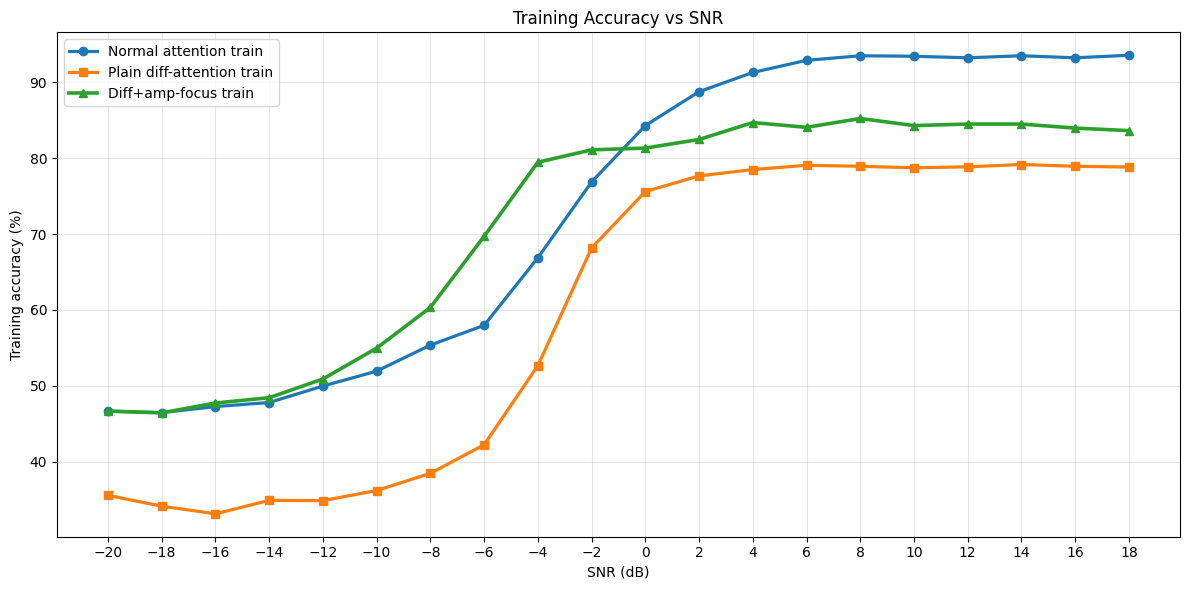

Saved: experiments/5class_diffattention_amp_focus/comparison_with_normal_and_diffattention/normal_plain_diff_vs_amp_focus_train_acc_vs_snr.png


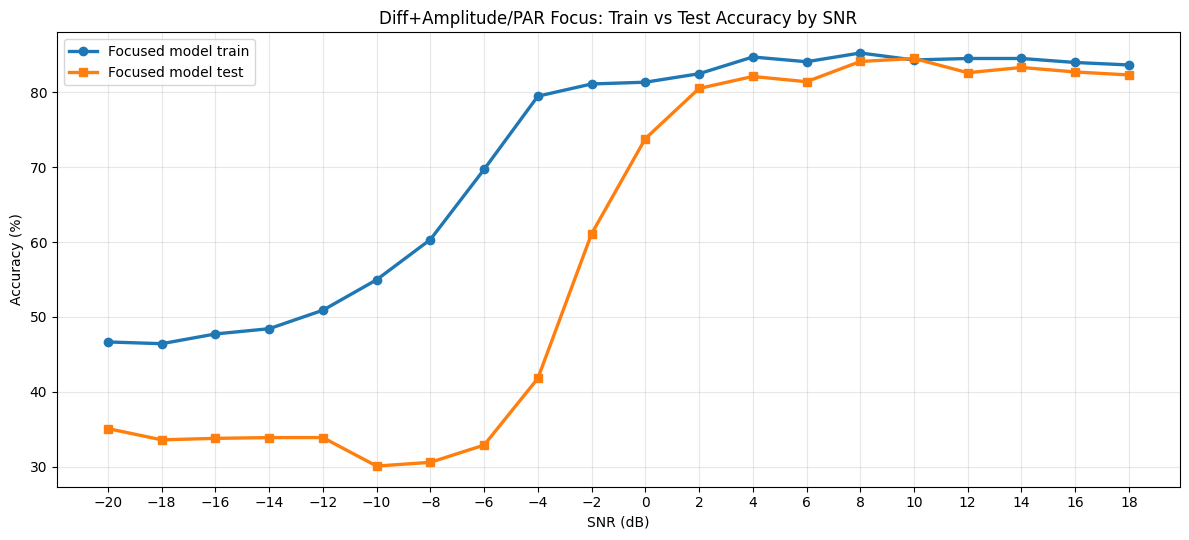

Saved: experiments/5class_diffattention_amp_focus/comparison_with_normal_and_diffattention/amp_focus_train_test_acc_per_snr.csv
Saved: experiments/5class_diffattention_amp_focus/comparison_with_normal_and_diffattention/amp_focus_train_vs_test_acc_by_snr.png


In [10]:
# CELL 8: Plot training accuracy vs SNR and train-vs-test for focused model
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(train_comparison["snr"], train_comparison["normal_attention_train_acc_percent"], marker="o", linewidth=2.3, label="Normal attention train")
ax.plot(train_comparison["snr"], train_comparison["plain_diffattention_train_acc_percent"], marker="s", linewidth=2.3, label="Plain diff-attention train")
ax.plot(train_comparison["snr"], train_comparison["diffattention_amp_focus_train_acc_percent"], marker="^", linewidth=2.6, label="Diff+amp-focus train")
ax.set_title("Training Accuracy vs SNR")
ax.set_xlabel("SNR (dB)")
ax.set_ylabel("Training accuracy (%)")
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xticks(train_comparison["snr"])
plt.tight_layout()
train_curve_path = COMPARE_DIR / "normal_plain_diff_vs_amp_focus_train_acc_vs_snr.png"
fig.savefig(train_curve_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {train_curve_path}")

train_test = pd.merge(
    comparison[["snr", "diffattention_amp_focus_acc"]],
    train_comparison[["snr", "diffattention_amp_focus_train_acc"]],
    on="snr",
    how="inner",
)
train_test["focus_test_acc_percent"] = 100.0 * train_test["diffattention_amp_focus_acc"]
train_test["focus_train_acc_percent"] = 100.0 * train_test["diffattention_amp_focus_train_acc"]
train_test_csv = COMPARE_DIR / "amp_focus_train_test_acc_per_snr.csv"
train_test.to_csv(train_test_csv, index=False)

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(train_test["snr"], train_test["focus_train_acc_percent"], marker="o", linewidth=2.4, label="Focused model train")
ax.plot(train_test["snr"], train_test["focus_test_acc_percent"], marker="s", linewidth=2.4, label="Focused model test")
ax.set_title("Diff+Amplitude/PAR Focus: Train vs Test Accuracy by SNR")
ax.set_xlabel("SNR (dB)")
ax.set_ylabel("Accuracy (%)")
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xticks(train_test["snr"])
plt.tight_layout()
train_vs_test_path = COMPARE_DIR / "amp_focus_train_vs_test_acc_by_snr.png"
fig.savefig(train_vs_test_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {train_test_csv}")
print(f"Saved: {train_vs_test_path}")


In [11]:
# CELL 9: Copy comparison files into focused-model results folder
# This keeps the final zip self-contained while not exporting baseline checkpoints/results.

FOCUS_COMPARE_EXPORT = FOCUS_DIR / "results" / "comparison_with_normal_and_diffattention"
FOCUS_COMPARE_EXPORT.mkdir(parents=True, exist_ok=True)

files_to_copy = [
    summary_csv,
    comparison_csv,
    curve_path,
    delta_path,
    train_comparison_csv,
    train_curve_path,
    train_test_csv,
    train_vs_test_path,
]

for src in files_to_copy:
    dst = FOCUS_COMPARE_EXPORT / Path(src).name
    shutil.copy2(src, dst)
    print(f"Copied: {dst}")


Copied: experiments/5class_diffattention_amp_focus/results/comparison_with_normal_and_diffattention/normal_plain_diff_vs_amp_focus_summary.csv
Copied: experiments/5class_diffattention_amp_focus/results/comparison_with_normal_and_diffattention/normal_plain_diff_vs_amp_focus_acc_per_snr.csv
Copied: experiments/5class_diffattention_amp_focus/results/comparison_with_normal_and_diffattention/normal_plain_diff_vs_amp_focus_acc_vs_snr.png
Copied: experiments/5class_diffattention_amp_focus/results/comparison_with_normal_and_diffattention/amp_focus_delta_by_snr.png
Copied: experiments/5class_diffattention_amp_focus/results/comparison_with_normal_and_diffattention/normal_plain_diff_vs_amp_focus_train_acc_per_snr.csv
Copied: experiments/5class_diffattention_amp_focus/results/comparison_with_normal_and_diffattention/normal_plain_diff_vs_amp_focus_train_acc_vs_snr.png
Copied: experiments/5class_diffattention_amp_focus/results/comparison_with_normal_and_diffattention/amp_focus_train_test_acc_per_snr

In [12]:
# CELL 10: Create repo-ready zip for ONLY focused diff-attention results
# The zip contains: experiments/5class_diffattention_amp_focus/...
# Extract it at repo root and paths line up with other experiment folders.

stamp = datetime.now().strftime("%Y%m%d_%H%M")
zip_base = Path("/kaggle/working") / f"diffattention_amp_focus_repo_ready_{stamp}"
zip_path = shutil.make_archive(
    str(zip_base),
    "zip",
    root_dir=str(WORK_DIR),
    base_dir="experiments/5class_diffattention_amp_focus",
)

print(f"Created repo-ready zip: {zip_path}")
print("\nExtract this zip at the repo root. It will create/update:")
print("  experiments/5class_diffattention_amp_focus/")
print("\nIncluded files:")
for path in sorted(FOCUS_DIR.rglob("*")):
    if path.is_file():
        print(" -", Path("experiments/5class_diffattention_amp_focus") / path.relative_to(FOCUS_DIR))

display(FileLink(zip_path))


Created repo-ready zip: /kaggle/working/diffattention_amp_focus_repo_ready_20260701_2018.zip

Extract this zip at the repo root. It will create/update:
  experiments/5class_diffattention_amp_focus/

Included files:
 - experiments/5class_diffattention_amp_focus/checkpoints/best_model.weights.h5
 - experiments/5class_diffattention_amp_focus/comparison_with_normal_and_diffattention/amp_focus_delta_by_snr.png
 - experiments/5class_diffattention_amp_focus/comparison_with_normal_and_diffattention/amp_focus_train_test_acc_per_snr.csv
 - experiments/5class_diffattention_amp_focus/comparison_with_normal_and_diffattention/amp_focus_train_vs_test_acc_by_snr.png
 - experiments/5class_diffattention_amp_focus/comparison_with_normal_and_diffattention/normal_plain_diff_vs_amp_focus_acc_per_snr.csv
 - experiments/5class_diffattention_amp_focus/comparison_with_normal_and_diffattention/normal_plain_diff_vs_amp_focus_acc_vs_snr.png
 - experiments/5class_diffattention_amp_focus/comparison_with_normal_and_d

/kaggle/working/diffattention_amp_focus_repo_ready_20260701_2018.zip